
#  Classification — Breast Cancer 

##  데이터 준비

In [ ]:
# 데이터 준비
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# 데이터 로드
cancer = load_breast_cancer()
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df['target'] = cancer.target  # 0=악성(malignant), 1=양성(benign)
print(df['target'].head())

# shape, describe, value_counts
print('데이터 shape :', df.shape)
print('데이터 describe :')
print(df.describe().round(3))
print(f'클래스 분포 : {df['target'].value_counts().rename({0:'악성', 1:'양성'})}')
print(f'악성 비율 = {(df["target"]==0).sum()/len(df)*100:.2f}% , 양성 비율 = {(df["target"]==1).sum()/len(df)*100:.2f}%')

# train:test = 7:3 분리 (random_state=42) 
X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42) # 비율 유지 안함 
print(f'  X_train: {X_train.shape} , X_test: {X_test.shape}')

# standardscaler (모든 변수를 평균=0, 표준편차=1로 맞추기)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),      columns=X.columns)  # test 데이터는 train 데이터에 맞춰진 변환을 사용


0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64
데이터 shape : (569, 31)
데이터 describe :
       mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
count      569.000       569.000         569.000    569.000          569.000   
mean        14.127        19.290          91.969    654.889            0.096   
std          3.524         4.301          24.299    351.914            0.014   
min          6.981         9.710          43.790    143.500            0.053   
25%         11.700        16.170          75.170    420.300            0.086   
50%         13.370        18.840          86.240    551.100            0.096   
75%         15.780        21.800         104.100    782.700            0.105   
max         28.110        39.280         188.500   2501.000            0.163   

       mean compactness  mean concavity  mean concave points  mean symmetry  \
count           569.000         569.000              569.000        569.000   
mean              0.10

각 변수 결측값 있는지 확인
전체 결측치 개수 = 0
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothn

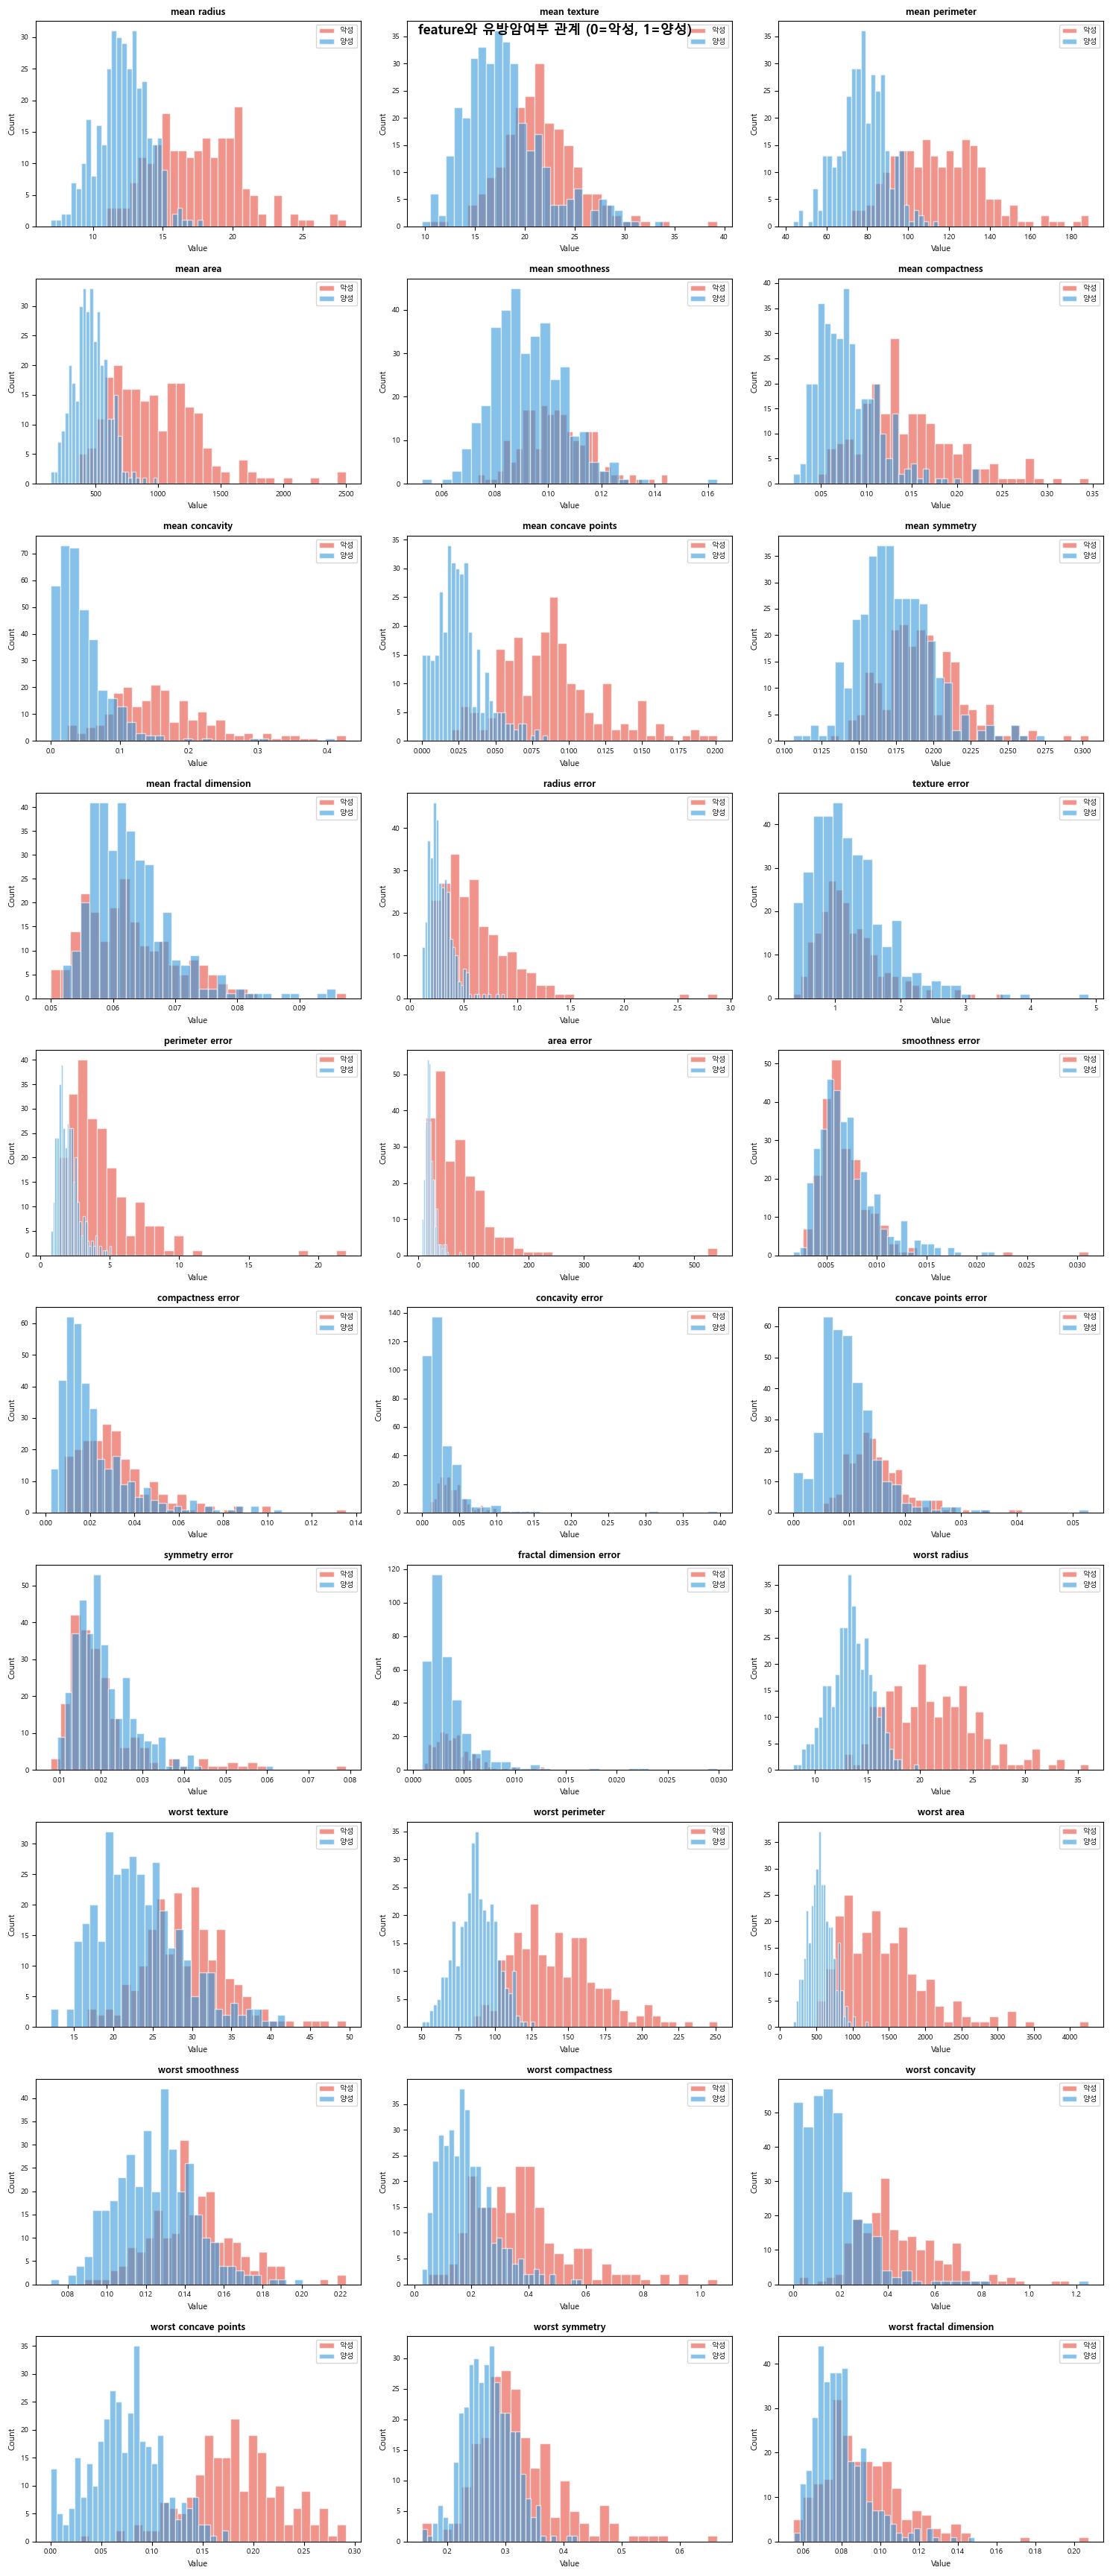

In [ ]:
# feature 살펴보기
print('각 변수 결측값 있는지 확인')
#print(df.isnull().sum().sort_values(ascending=False))
print(f'전체 결측치 개수 = {df.isnull().sum().sum()}')

print(df.info())

# 악성 , 양성 비율 
print(f'\nTrain 데이터에서 비율: {y_train.value_counts().to_dict()}')
print(f'Test 데이터에서 비율: {y_test.value_counts().to_dict()}')

features = df.columns

import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(10, 3, figsize=(15, 35))
fig.suptitle('feature와 유방암여부 관계 (0=악성, 1=양성)',
             fontsize=13, fontweight='bold')

for ax, feat in zip(axes.flatten(), features):
    for label, color, name in [(0, '#E74C3C', '악성'), (1, '#3498DB', '양성')]:
        vals = df[df['target'] == label][feat]
        ax.hist(vals, bins=30, alpha=0.6, color=color, label=name, edgecolor='white')
    ax.set_title(feat, fontsize=9, fontweight='bold')
    ax.set_xlabel('Value', fontsize=8)
    ax.set_ylabel('Count', fontsize=8)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.show()


 < 데이터 분포 >
> 모든 변수에 결측치가 없고 train데이터에서는 양성이 249개, 악성이 149개이다. 그리고 test 데이터에서는 양성이 108개, 악성이 63개이다. train데이터와 test데이터에서 양성과 악성의 비율이 완전히 동일하지는 않지만 데이터 크기가 크고 비율이 극단적으로 차이가 나는 것은 아니기 때문에 문제가 될 것 같진 않아 보인다.

 < feature 와 유방암 여부 분석 >
> 대부분의 feature들에서는 어느 값을 기준으로 넘어가면 악성, 그 값보다 작으면 양성인 경우로 비교적 나눠지는데, 그래프를 보면 mean smoothness, mean symmetry, mean fractal dimension, texture error, smoothness error, compactness error, concavity error, concave points error, symmetry error, fractal dimension error, worst texture, worst smoothness, worst fractal dimension 이 변수들은 양성과 악성이 어느 기준으로 나뉘지 않고 비슷한 값들을 가진다. 따라서 이 변수들은 유방암을 진단하는데 그렇게 의미가 있지는 않을 것으로 예상한다.

##  KNN (K-Nearest Neighbors) 

k별 KNN 성능 표:


,k,Train Acc,Test Acc
0,1,1.0000,0.9532
1,3,0.9874,0.9591
2,5,0.9774,0.9591
3,7,0.9698,0.9591
4,9,0.9774,0.9708
5,11,0.9724,0.9708
6,13,0.9673,0.9649
7,15,0.9648,0.9532


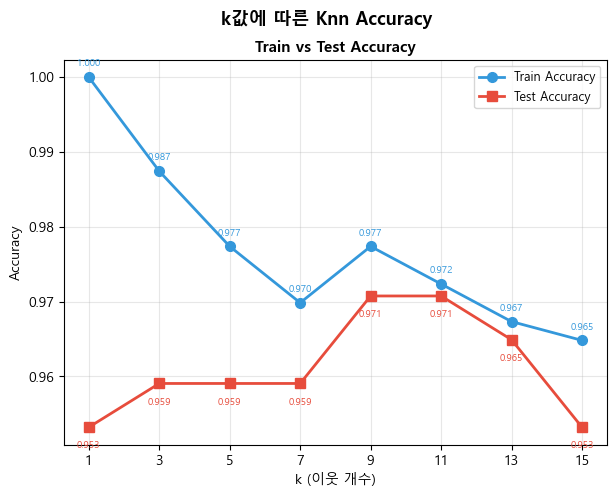

In [ ]:
#  KNN — k 값별 accuracy 계산 및 시각화
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

k_values = [1, 3, 5, 7, 9, 11, 13, 15]

from sklearn.metrics import  f1_score

train_accs, test_accs = [], []
train_f1s,  test_f1s  = [], []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    
    tr_pred = knn.predict(X_train_scaled)
    te_pred = knn.predict(X_test_scaled)
    
    train_accs.append(accuracy_score(y_train, tr_pred))
    test_accs.append(accuracy_score(y_test,  te_pred))
    train_f1s.append(f1_score(y_train, tr_pred))
    test_f1s.append(f1_score(y_test,  te_pred))

# 결과 DataFrame 출력
knn_df = pd.DataFrame({
    'k': k_values,
    'Train Acc': train_accs, 'Test Acc': test_accs
})
print('k별 KNN 성능 표:')
display(knn_df.round(4))


# 그래프 Accuracy 곡선 
fig, ax = plt.subplots(figsize=(7, 5))
fig.suptitle('k값에 따른 Knn Accuracy', fontsize=13, fontweight='bold')

ax.plot(k_values, train_accs, 'o-', color='#3498DB', lw=2, ms=7, label='Train Accuracy')
ax.plot(k_values, test_accs,  's-', color='#E74C3C', lw=2, ms=7, label='Test Accuracy')
ax.set_xlabel('k (이웃 개수)', fontsize=10)
ax.set_ylabel('Accuracy', fontsize=10)
ax.set_title('Train vs Test Accuracy', fontsize=11, fontweight='bold')
ax.set_xticks(k_values)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
for k, tr, te in zip(k_values, train_accs, test_accs):
    ax.annotate(f'{te:.3f}', (k, te), textcoords='offset points',
                 xytext=(0, -15), ha='center', fontsize=7, color='#E74C3C')
    ax.annotate(f'{tr:.3f}', (k, tr), textcoords='offset points',
                xytext=(0, 8), ha='center', fontsize=7, color='#3498DB')

(2) 최적 k 선택 근거

> 최적 k = 9 , 그래프를 보면 k가 9 보다 작을 때는 train 데이터에 대해서는 성능이 매우 우수하지만 이에 비해 test 데이터에 대해서는 성능이 다소 떨어지는 것을 볼 수 있다. 이는 모델이 훈련데이터의 소수의 점에만 의존하여 과적합이 된 것으로 보인다. k가 9보다 클 때는 train 데이터와 test 데이터 둘 다에 대해 성능이 계속 떨어진다. 이것은 너무 일반화가 되어 과소적합 되어서 모델의 성능이 떨어지는 것으로 보인다. 따라서 train 데이터와 test 데이터 각각의 성능이 우수하고 둘의 차이도 얼마 나지 않는 k값인 9가 최적의 k라고 생각한다. 

(3) KNN 원리 해석

> k가 너무 작을 때, 예를 들어 k = 1 이라면 자기 자신과 거리가 0으로 가장 가깝기 때문에 train 데이터에서 정확도=1이 된다. 이것은 모델이 train 데이터의 노이즈까지 완벽히 암기한 것으로 새로운 데이터에는 일반화가 되어있지 않기 때문에 test 데이터에 대해서는 성능이 떨어질 수 밖에 없다. 다른 말로 train 데이터에서의 성능은 우수하지만 test 데이터에 대해서는 성능이 좋지 않은 과적합이 발생할 확률이 매우 크다.
> k가 너무 클 때, 예를 들어 k가 전체 데이터 수에 가까워질 때를 생각해보면 knn 모델은 해당 점과 거리가 가까운 점 k개를 기준으로 더 많이 속해있는 그룹으로 분류가 되는 것인데 k가 전체 데이터 수에 가깝다면, 사실상 전체 데이터 중 속해있는 데이터의 수가 많은 클래스로 분류가 된다. 예를 들어 특정 암에 걸린 사람보다 암에 걸리지 않은 사람의 수가 많다면 그냥 암에 걸리지 않았다고 예측할 가능성이 커진다. 따라서 k값이 너무 크면 데이터를 단순화해버리고 과소적합이 발생할 확률이 커진다.
> knn에서 StandardScaler를 반드시 해야하는 이유는 knn은 두 점(데이터)사이의 유클리드 거리를 기반으로 가까운 이웃들을 k개 찾고 그 이웃들 중 과반수 이상인 그룹으로 분류를 하는데, 만약 feature마다 스케일이 다르면 스케일이 큰 feature의 거리 차이가 거리 계산을 지배하게 된다. 즉 스케일이 작은 feature는 사실상 무시되기 때문에 중요한 변수라도 스케일이 작다면 예측할 때 영향력이 없어져 오분류할 가능성이 커진다. 따라서 모든 feature들을 StandardScaler를 통해 평균 0 , 표준편차 1로 통일하여 거리계산에 동등하게 기여할 수 있도록 해야한다.

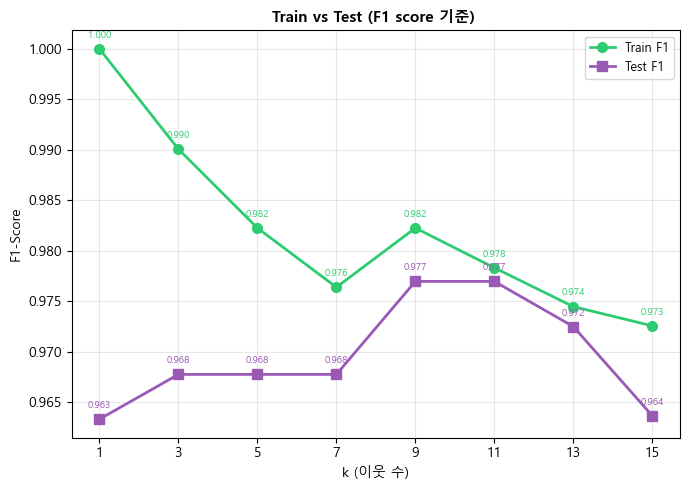


최적 k=9 Classification Report (Test):
              precision    recall  f1-score   support

       악성(0)       0.97      0.95      0.96        63
       양성(1)       0.97      0.98      0.98       108

    accuracy                           0.97       171
   macro avg       0.97      0.97      0.97       171
weighted avg       0.97      0.97      0.97       171



In [ ]:

from sklearn.metrics import classification_report

# 그래프: F1-score 
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(k_values, train_f1s, 'o-', color='#2ECC71', lw=2, ms=7, label='Train F1')
ax.plot(k_values, test_f1s,  's-', color='#9B59B6', lw=2, ms=7, label='Test F1')
ax.set_xlabel('k (이웃 수)', fontsize=10)
ax.set_ylabel('F1-Score', fontsize=10)
ax.set_title('Train vs Test (F1 score 기준) ', fontsize=11, fontweight='bold')
ax.set_xticks(k_values)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
for k, tef, trf in zip(k_values, test_f1s, train_f1s):
    ax.annotate(f'{tef:.3f}', (k, tef), textcoords='offset points',
                 xytext=(0, 8), ha='center', fontsize=7, color='#9B59B6')
    ax.annotate(f'{trf:.3f}', (k, trf), textcoords='offset points',
                xytext=(0, 8), ha='center', fontsize=7, color='#2ECC71')

plt.tight_layout()
plt.show()


# 최적의 k인 k = 9 일 때 모델 classification_report
print(f'\n최적 k=9 Classification Report (Test):')
best_knn = KNeighborsClassifier(n_neighbors=9)
best_knn.fit(X_train_scaled, y_train)
print(classification_report(y_test, best_knn.predict(X_test_scaled),
                             target_names=['악성(0)', '양성(1)']))

 < f1 score 기준 모델 성능 평가 >
> accuracy 지표말고 f1 score를 기준으로 봤을 때 k가 9 미만일 때는 train데이터 성능은 우수하지만 이에 비해 test데이터 성능은 다소 떨어지는 것이 보인다. 
반대로 9를 넘어갔을 때는 train데이터 성능과 test데이터 성능이 지속적으로 감소하고 있다. 
이는 k < 9 일 때는 과적합이, k > 9 일 때는 과소적합이 된 것으로 보이기 때문에 
f1 score을 기준으로 봤을 때 최적의 k값은 train데이터와 test 데이터의 성능이 모두 우수하고 그 성능 차이가 별로 나지 않는 9라고 생각한다.


##  SVM (Support Vector Machine) 


c가 1일 때 test accuracy = 0.977


C값에 따른 accuracy :
        C  Train Acc  Test Acc
0    0.01   0.977387  0.988304
1    0.10   0.982412  0.982456
2    1.00   0.989950  0.976608
3   10.00   0.994975  0.964912
4  100.00   0.997487  0.929825


test accuracy가 최대가 되는 C = 0.01  (Test Accuracy = 0.9883)



c:\Users\홍은유\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


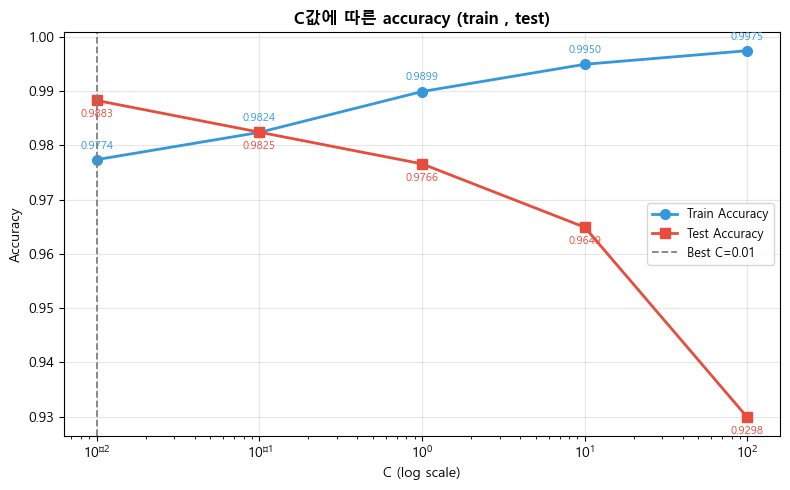

In [ ]:
#  SVM — Pipeline 구현 및 C 값 실험
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

C_values = [0.01, 0.1, 1, 10, 100]


# c가 1일 때 
svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', LinearSVC(C=1, loss='hinge', max_iter=10000))
])

svm.fit(X_train, y_train)
test_pred = svm.predict(X_test)
print(f'c가 1일 때 test accuracy = {accuracy_score(y_test, test_pred):.3f}\n')

# c가 0.01, 0.1, 1, 10, 100 일 때 
from sklearn.metrics import precision_score, recall_score, f1_score

svm_results = []

for C in C_values:
    svm = Pipeline([
        ('scaler', StandardScaler()),
        ('svc', LinearSVC(C=C, loss='hinge', max_iter=10000))
    ])
    svm.fit(X_train, y_train)  # Pipeline 내부에 scaler 포함이므로 원본 데이터 사용
    
    tr_pred = svm.predict(X_train)
    te_pred = svm.predict(X_test)
    
    svm_results.append({
        'C': C,
        'Train Acc':  accuracy_score(y_train, tr_pred),
        'Test Acc':   accuracy_score(y_test,  te_pred),
        'Precision':  precision_score(y_test, te_pred),
        'Recall':     recall_score(y_test,    te_pred),
        'F1':         f1_score(y_test,        te_pred),
    })

svm_df = pd.DataFrame(svm_results)
print(f'\nC값에 따른 accuracy :')
print(f'{svm_df.iloc[:,0:3]}\n')

best_svm_row = svm_df.loc[svm_df['Test Acc'].idxmax()]
print(f'\ntest accuracy가 최대가 되는 C = {best_svm_row["C"]}  (Test Accuracy = {best_svm_row["Test Acc"]:.4f})\n')

# 그래프: Train vs Test Accuracy 
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(svm_df['C'], svm_df['Train Acc'], 'o-', color='#3498DB', lw=2, ms=7, label='Train Accuracy')
ax.plot(svm_df['C'], svm_df['Test Acc'],  's-', color='#E74C3C', lw=2, ms=7, label='Test Accuracy')
ax.axvline(best_svm_row['C'], color='gray', linestyle='--', lw=1.3,
           label=f'Best C={best_svm_row["C"]}')
ax.set_xscale('log')
ax.set_xlabel('C (log scale)', fontsize=10)
ax.set_ylabel('Accuracy', fontsize=10)
ax.set_title('C값에 따른 accuracy (train , test)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
for _, row in svm_df.iterrows():
    ax.annotate(f"{row['Test Acc']:.4f}", (row['C'], row['Test Acc']),
                textcoords='offset points', xytext=(0, -12),
                ha='center', fontsize=8, color='#E74C3C')
    ax.annotate(f"{row['Train Acc']:.4f}", (row['C'], row['Train Acc']),
                textcoords='offset points', xytext=(0, 8),
                ha='center', fontsize=8, color='#3498DB')
plt.tight_layout()
plt.show()



(2) SVM 원리 해석

> svm은 클래스 사이의 간격인 마진을 최대화하는 경계단면을 찾는 것을 목표로 한다. 여기서 마진은 경계단면으로 부터 각 클래스의 가장 가까운 샘플까지의 거리 합을 의미하고 마진이 클수록 일반화가 되어 새로운 데이터에 대해서도 성능이 좋을 수 있다. 즉 마진을 크게 하면 train 데이터에 대해서는 성능이 약간 떨어질 수 있지만 test 데이터나 검증데이터 등 새로운 데이터에 대해서는 성능이 좋아질 수 있다. 서포트벡터는 경계 단면에 가장 가까이 위치한 샘플들을 의미하는데 경계 단면의 위치와 방향을 결정하는 중요한 역할을 한다. 이때 서포트벡터들끼리는 다른 그룹에 속해있더라도 유사성이 높을 수 있기 때문에 그 데이터들을 민감하게 분류해야 모델의 성능이 좋아질 수 있다.
C는 missclassification 즉 분류 오류에 대해 가중치를 얼마나 둘건지를 의미하는 값이다. C값이 작을수록 데이터가 경계단면을 넘어가 반대쪽에 위치하는 오류인 분류오류를 어느정도 허용하면서 마진을 크게 유지하고, C값이 클수록 마진을 크게하는 것보다 분류오류를 감소시키는데 매우 중점을 두게 된다. 실험결과를 보면 C값이 커질수록 train 데이터에 대한 성능은 증가하고 test 데이터에 대한 성능은 감소하는 것을 볼 수 있고 특히 C가 100일 때는 train 데이터에서는 0.998 , test 데이터에 대해서는 0.930으로 성능차이가 나는 것을 볼 수 있다. 이는 train 데이터에서 분류오류를 줄이는 것에 너무 집중한 나머지 과적합되었음을 알 수 있다. 즉 C값이 너무 커지면 과적합이 발생하게 된다. 

In [ ]:

# accuracy 이외의 성능지표들 
print('C값에 따른 SVM 성능 표:')
display(svm_df.round(4))

# C=1 기준 classification_report
print('\nC=1 SVM Classification Report (Test):')
svm_c1 = Pipeline([('scaler', StandardScaler()),
                    ('svc', LinearSVC(C=1, loss='hinge', max_iter=10000))])
svm_c1.fit(X_train, y_train)
print(classification_report(y_test, svm_c1.predict(X_test),
                             target_names=['Malignant(0)', 'Benign(1)']))

C값에 따른 SVM 성능 표:


,C,Train Acc,Test Acc,Precision,Recall,F1
0,0.01,0.9774,0.9883,0.9818,1.0000,0.9908
1,0.10,0.9824,0.9825,0.9817,0.9907,0.9862
2,1.00,0.9899,0.9766,0.9815,0.9815,0.9815
3,10.00,0.9950,0.9649,0.9811,0.9630,0.9720
4,100.00,0.9975,0.9298,0.9800,0.9074,0.9423



C=1 SVM Classification Report (Test):
              precision    recall  f1-score   support

Malignant(0)       0.97      0.97      0.97        63
   Benign(1)       0.98      0.98      0.98       108

    accuracy                           0.98       171
   macro avg       0.97      0.97      0.97       171
weighted avg       0.98      0.98      0.98       171



 < C값에 따른 성능표 분석 >
> svm 모델에서 C값이 증가할 때 Precision 점수는 0.98정도로 일정하게 유지되는 반면 Recall 점수는 0.99에서 0.91까지 떨어지는 것을 볼 수 있다. 이는 C값이 커질수록 모델의 경계단면이 복잡해지면서 과적합이 발생하는 것으로 보인다. 이때 Precision과 Recall의 조화평균인 f1 score 또한 하락하고 있음을 확인할 수 있다. 따라서 실제환자를 질병으로 분류하는 Recall이 중요한 의료데이터의 특성을 고려하면 일반화성능과 Recall 점수가 모두 가장 우수한 0.01이 가장 최적의 C값이라고 생각한다.

##  Decision Tree 



[Gini]  Train Acc: 0.987 | Test Acc: 0.965
              precision    recall  f1-score   support

       악성(0)       0.95      0.95      0.95        63
       양성(1)       0.97      0.97      0.97       108

    accuracy                           0.96       171
   macro avg       0.96      0.96      0.96       171
weighted avg       0.96      0.96      0.96       171


[Entropy]  Train Acc: 0.985 | Test Acc: 0.977
              precision    recall  f1-score   support

       악성(0)       0.98      0.95      0.97        63
       양성(1)       0.97      0.99      0.98       108

    accuracy                           0.98       171
   macro avg       0.98      0.97      0.97       171
weighted avg       0.98      0.98      0.98       171


이 점수를 기준으로 보면 gini보다 entropy를 사용했을 때 test accuracy 점수가 더 높다.


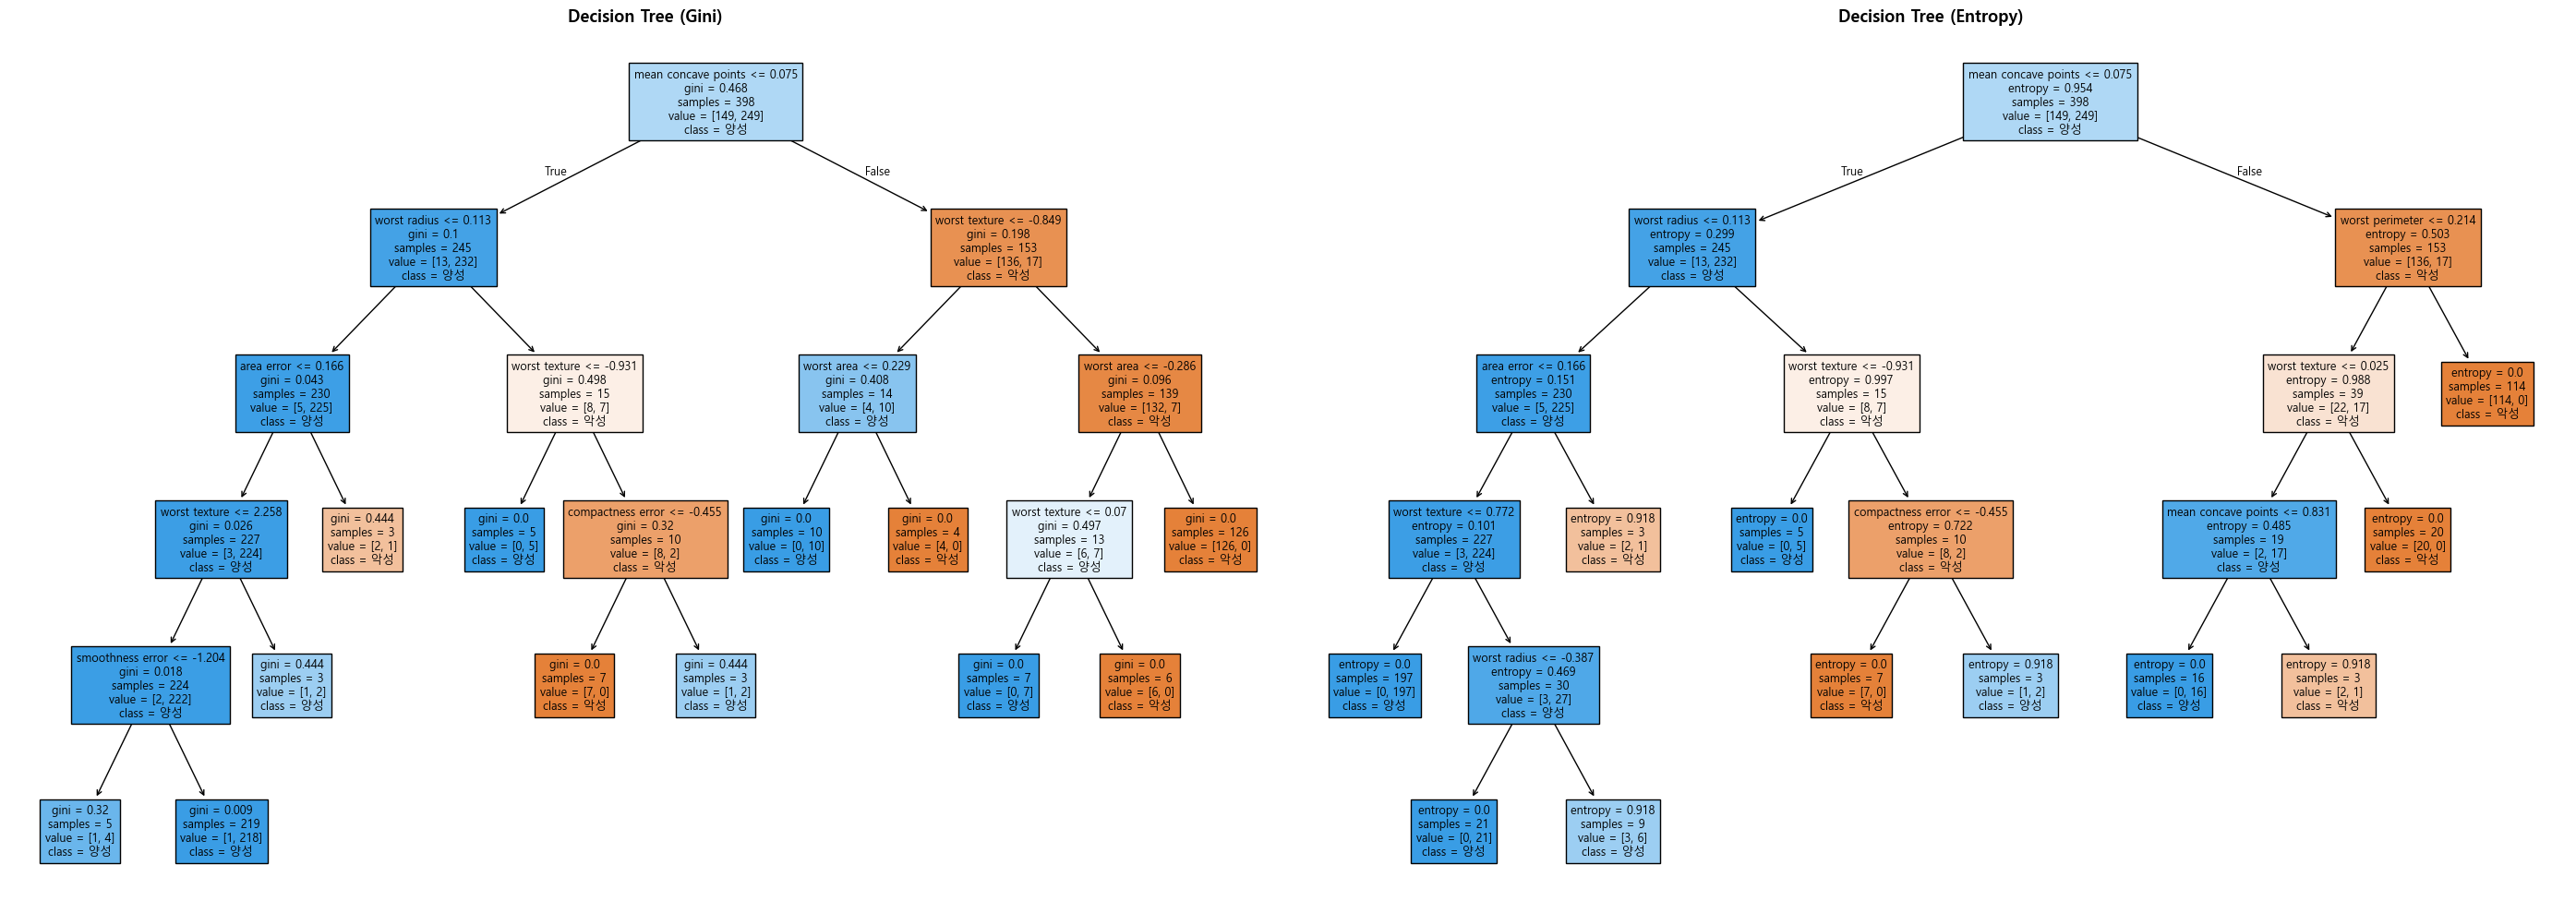

In [ ]:
# Decision Tree — gini vs entropy 비교
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt

# 여기에 코드를 작성하시오

# 모델 정의
clf_gini    = DecisionTreeClassifier(criterion='gini',    max_depth=5, min_samples_leaf=3, random_state=42)
clf_entropy = DecisionTreeClassifier(criterion='entropy', max_depth=5, min_samples_leaf=3, random_state=42)

# 학습
clf_gini.fit(X_train_scaled, y_train)
clf_entropy.fit(X_train_scaled, y_train)

# 성능 출력
for name, clf in [('Gini', clf_gini), ('Entropy', clf_entropy)]:
    tr_acc = accuracy_score(y_train, clf.predict(X_train_scaled))
    te_acc = accuracy_score(y_test,  clf.predict(X_test_scaled))
    print(f'\n[{name}]  Train Acc: {tr_acc:.3f} | Test Acc: {te_acc:.3f}')
    print(classification_report(y_test, clf.predict(X_test_scaled),
                                 target_names=['악성(0)', '양성(1)']))
    
print(f'\n이 점수를 기준으로 보면 gini보다 entropy를 사용했을 때 test accuracy 점수가 더 높다.')

# plot_tree 시각화 
fig, axes = plt.subplots(1, 2, figsize=(28, 10))
for ax, clf, name in zip(axes, [clf_gini, clf_entropy], ['Gini', 'Entropy']):
    plot_tree(clf, ax=ax, filled=True, fontsize=9,
              feature_names=list(X.columns),
              class_names=['악성', '양성'])
    ax.set_title(f'Decision Tree ({name})', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

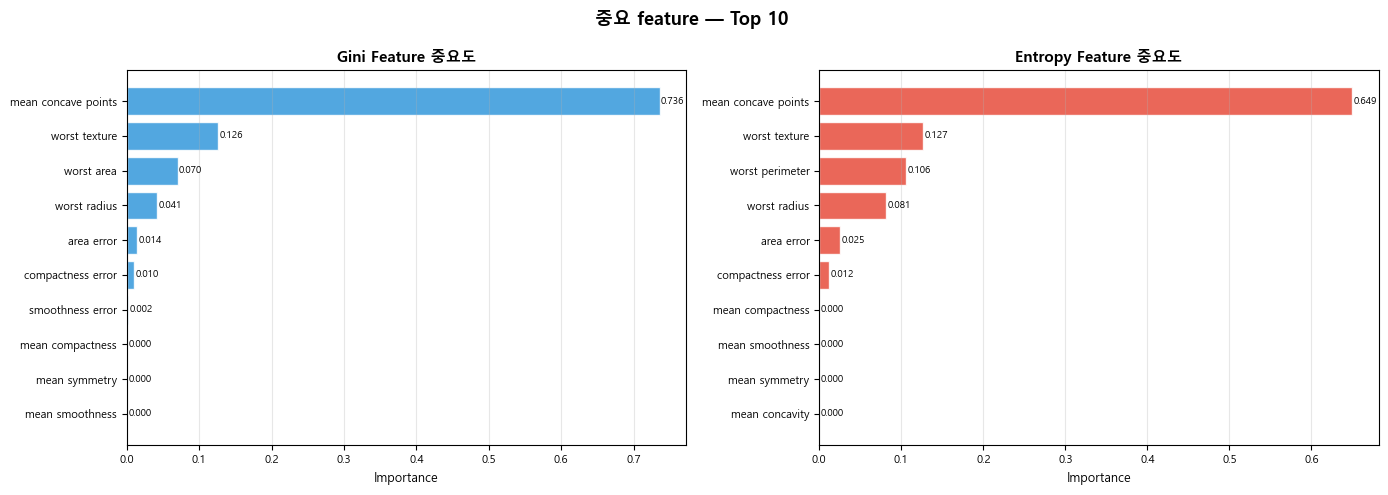

In [ ]:

# gini , entropy 각각에서 중요한 상위 10개 feature
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('중요 feature — Top 10 ', fontsize=13, fontweight='bold')

for ax, clf, name, color in zip(axes, [clf_gini, clf_entropy],
                                 ['Gini', 'Entropy'], ['#3498DB', '#E74C3C']):
    fi = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False)[:10]
    ax.barh(fi.index[::-1], fi.values[::-1], color=color, edgecolor='white', alpha=0.85)
    ax.set_title(f'{name} Feature 중요도', fontsize=11, fontweight='bold')
    ax.set_xlabel('Importance', fontsize=9)
    ax.tick_params(labelsize=8)
    for i, (val, label) in enumerate(zip(fi.values[::-1], fi.index[::-1])):
        ax.text(val + 0.002, i, f'{val:.3f}', va='center', fontsize=7)
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

< gini / entropy 각각에서 가장 중요한 변수 분석 >
> gini와 entropy 방식에서 모두 mean concave points가 압도적으로 중요한 변수이며 상위 3~4개 변수만으로 모델 예측의 대부분이 설명됨을 보여준다. 다만 gini 방식은 특정 변수에 중요도를 강하게 편중시키는 반면 엔트로피는 로그 스케일을 사용하고 정보량을 더 세밀하게 평가하여 하위 변수들에게 중요도를 비교적 고르게 분산시킨다. 이 과정에서 두 방식의 수학적 기준 차이로 인해 worst parameter 같은 변수의 순위가 미세하게 뒤바뀌는 현상이 발생하지만 이는 불순도를 측정하는 관점의 차이일 뿐 데이터의 오류는 아니다.

(2) Gini vs Entropy 해석

> gini impurity는 통계적 관점에서 보면 데이터에서 샘플을 하나 뽑았을 때 그 샘플을 잘못 분류할 확률이다. 즉 이 데이터가 얼마나 섞여있는지를 통계적확률로 나타낸 것인데 제곱 연산을 사용하기 때문에 계산이 상대적으로 빠르다. 또한 특정 클래스가 얼마나 지배적인지를 빠르게 파악하며 데이터의 종속변수가 이진분할 되어있고 한 클래스의 비율이 높을 때 효과적이다. 정리하면 데이터가 얼마나 잘 섞여있는가 보다는 한 클래스가 지배적인가를 측정하는데 유리하고 그렇기 때문에 데이터 내 특정 클래스 비율이 압도적이며 데이터의 양이 방대하여 학습시간을 단축해야하는 상황에서 적합하다. 
> entropy는 데이터의 무질서도 또는 불확실성을 수치화한 것으로 어떤 속성을 기준으로 데이터를 나누었을 때 불확실성이 얼마나 줄어드는지를 계산하는데 사용한다. 즉 정보 획득량을 극대화하는 방식이고 여러 클래스가 섞여있어서 복잡한 분포를 더 세밀하게 파악해야할 때 유리하다. 따라서 계산 속도보다 모델의 판단 근거가 중요하거나 데이터의 무질서도를 최대한 낮추고 정밀한 정보량 측정이 필요할 때 적합하다.

> 현재 우리 모델을 각각 gini , entropy를 이용했을 때의 결과를 보면, 먼저 gini를 이용했을 때 train데이터의 정확도는 0.987, test데이터의 정확도는 0.965이다. entropy를 이용했을 때 train데이터의 정확도는 0.985, test데이터의 정확도는 0.977이다. train데이터에서는 gini를 이용했을 때 성능이 약 0.2% 좋고 test데이터에서는 entropy를 이용했을 때가 성능이 약 1.2% 더 우수하다. 현재 사용한 데이터에서는 둘의 차이가 유의미할 정도로 크게 나타나지 않았는데 이는 breast cancer 데이터의 클래스 간 경계가 비교적 뚜렷하여 어떤 지표를 사용하든 모두 비슷한 분기점을 찾기 때문인 것 같다. 하지만 만약 데이터가 복잡하고 불균형할 때는 해당되는 샘플이 별로 없는 소수 클래스의 특성을 정밀하게 파악해야 하므로 entropy를 사용했을 때의 모델 성능이 gini를 사용했을 때보다 더 우수할 것 같다. 

In [ ]:
# max_depth, min_samples_leaf 등 값 변화하며 모델 성능을 비교
from itertools import product

max_depths       = [3, 5, 10, None]
min_samples_list = [1, 3, 5, 10]
g_results = []
e_results = []

## gini
for md, msl in product(max_depths, min_samples_list):
    clf = DecisionTreeClassifier(criterion='gini', max_depth=md, min_samples_leaf=msl, random_state=42)
    clf.fit(X_train_scaled, y_train)
    tr_acc = accuracy_score(y_train, clf.predict(X_train_scaled))
    te_acc = accuracy_score(y_test,  clf.predict(X_test_scaled))
    g_results.append({
        'max_depth': str(md), 'min_samples_leaf': msl,
        'Train Acc': round(tr_acc, 4), 'Test Acc': round(te_acc, 4),
        'Gap': round(tr_acc - te_acc, 4)
    })

g_df = pd.DataFrame(g_results)
print('< gini 사용했을 때 max_depth & min_samples_leaf 조합별 성능 표 >')
display(g_df)

# 최적 조합 출력
best_g = g_df.loc[g_df['Test Acc'].idxmax()]
print(f'\n최적 조합: max_depth={best_g["max_depth"]}, '
      f'min_samples_leaf={best_g["min_samples_leaf"]}  '
      f'(Test Acc={best_g["Test Acc"]:.4f})')


## entropy 
for md, msl in product(max_depths, min_samples_list):
    clf = DecisionTreeClassifier(criterion='entropy', max_depth=md, min_samples_leaf=msl, random_state=42)
    clf.fit(X_train_scaled, y_train)
    tr_acc = accuracy_score(y_train, clf.predict(X_train_scaled))
    te_acc = accuracy_score(y_test,  clf.predict(X_test_scaled))
    e_results.append({
        'max_depth': str(md), 'min_samples_leaf': msl,
        'Train Acc': round(tr_acc, 4), 'Test Acc': round(te_acc, 4),
        'Gap': round(tr_acc - te_acc, 4)
    })

e_df = pd.DataFrame(e_results)
print('\n< entropy 사용했을 때 max_depth & min_samples_leaf 조합별 성능 표 >')
display(e_df)

# 최적 조합 출력
best_e = e_df.loc[e_df['Test Acc'].idxmax()]
print(f'\n최적 조합: max_depth={best_e["max_depth"]}, '
      f'min_samples_leaf={best_e["min_samples_leaf"]}  '
      f'(Test Acc={best_e["Test Acc"]:.4f})')

< gini 사용했을 때 max_depth & min_samples_leaf 조합별 성능 표 >


,max_depth,min_samples_leaf,Train Acc,Test Acc,Gap
0,3,1,0.9698,0.9649,0.0049
1,3,3,0.9698,0.9649,0.0049
2,3,5,0.9648,0.9649,-0.0001
3,3,10,0.9447,0.9415,0.0032
4,5,1,0.9950,0.9532,0.0418
5,5,3,0.9874,0.9649,0.0225
6,5,5,0.9799,0.9708,0.0091
7,5,10,0.9447,0.9415,0.0032
8,10,1,1.0000,0.9415,0.0585
9,10,3,0.9874,0.9532,0.0342



최적 조합: max_depth=5, min_samples_leaf=5  (Test Acc=0.9708)

< entropy 사용했을 때 max_depth & min_samples_leaf 조합별 성능 표 >


,max_depth,min_samples_leaf,Train Acc,Test Acc,Gap
0,3,1,0.9799,0.9708,0.0091
1,3,3,0.9799,0.9708,0.0091
2,3,5,0.9774,0.9708,0.0066
3,3,10,0.9648,0.9649,-0.0001
4,5,1,0.9925,0.9532,0.0392
5,5,3,0.9849,0.9766,0.0083
6,5,5,0.9799,0.9708,0.0091
7,5,10,0.9648,0.9649,-0.0001
8,10,1,1.0000,0.9649,0.0351
9,10,3,0.9899,0.9532,0.0367



최적 조합: max_depth=5, min_samples_leaf=3  (Test Acc=0.9766)


(3) max_depth, min_samples_leaf 설정 근거

> max_depth에 따른 결과 : min_samples_leaf 값은 5로 고정시켰을 때 gini를 이용한 결과를 보면 max_depth값이 3,5,10,제한없음으로 증가함에 따라 train 데이터에 대한 정확도는 0.9648 , 0.9799로 증가함을 알 수 있다. 그런데 train데이터와 test데이터에 대한 성능 차이가 -0.0001에서 0.0091로 둘의 차이가 커짐을 확인할 수 있다. 이는 max_depth가 크면 train데이터에 대해 아주 섬세한 분류 모델이 만들어져서 train데이터 성능은 매우 우수하지만 test데이터 성능은 좋지 않은 과적합이 발생한다는 것을 의미한다. 반대로 max_depth가 3처럼 작으면 train, test 데이터 둘 다 성능이 떨어진다. 이는 max_depth가 너무 작으면 모델이 올바르게 분류를 잘 하지 못하는 과소적합이 발생한다는 것을 의미한다. 

> min_samples_leaf에 따른 결과 : min_samples_leaf는 리프노드가 되기 위해 필요한 최소한의 샘플 수를 의미하는데, max_depth 값은 5로 고정시켰을 때 gini를 이용한 결과를 보면 mini_samples_leaf값이 1,3,5,10으로 증가함에 따라 train 데이터에 대한 정확도는 0.995, 0.9874, 0.9799, 0.9447로 지속적으로 감소함한다. test데이터에 대한 정확도는 0.9532, 0.9649, 0.9708, 0.9415로 증가하였다가 감소한다. 이를 통해 min_samples_leaf가 매우 작으면 리프 노드가 매우 적은 수의 샘플만으로도 생성되기 때문에 train데이터에 대해서는 성능이 높지만 일반화가 안되는 과적합이 발생하고, min_samples_leaf가 너무 크면 각 리프가 너무 많은 수의 샘플을 포함해야하는 것을 강제하기 때문에 train데이터, test데이터에 대해 모두 성능이 떨어지는 과소적합이 발생한다는 것을 알 수 있다.

## 성능 분석 및 모델 비교 

In [ ]:
# 세 모델 성능 비교 표
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay)

# 각 모델 예측값 준비
best_knn = KNeighborsClassifier(n_neighbors=9)
best_knn.fit(X_train_scaled, y_train)

knn_pred   = best_knn.predict(X_test_scaled)
svm_pred   = svm_c1.predict(X_test)
gini_pred  = clf_gini.predict(X_test_scaled)

# 성능 비교 DataFrame
compare_results = []
for name, pred in [('KNN (k=9)', knn_pred),
                    ('SVM (C=1)',    svm_pred),
                    ('DT Gini',      gini_pred)]:
    compare_results.append({
        'Model':     name,
        'Accuracy':  accuracy_score(y_test,  pred),
        'Precision': precision_score(y_test, pred),
        'Recall':    recall_score(y_test,    pred),
        'F1-Score':  f1_score(y_test,        pred),
    })

compare_df = pd.DataFrame(compare_results)
print('세 모델 test 성능 비교표:')
display(compare_df.round(4))



세 모델 test 성능 비교표:


,Model,Accuracy,Precision,Recall,F1-Score
0,KNN (k=9),0.9708,0.9725,0.9815,0.9770
1,SVM (C=1),0.9766,0.9815,0.9815,0.9815
2,DT Gini,0.9649,0.9722,0.9722,0.9722


 (2) FN/FP 해석 및 Accuracy 한계

> FN(False Negative)는 정상으로 예측했지만 실제로는 병이 있는 것이고, FP(False Positive)는 병이 있다고 예측했지만 실제로는 병이 없는 것을 의미한다. 참고로 우리데이터에서는 0=암 1=정상이다. 유방암을 진단할 대는 FN이 FP보다 훨씬 위험하다. 그 이유는 FP인 환자는 정상인데 암이라고 잘못 판단한 경우인데, 잠시 심리적불안과 불필요한 추가 검사를 겪겠지만 후속 정밀 검사에서 오진이 밝혀질 확률이 높고 실질적인 생존에는 문제가 없다. 하지만 FN인 환자는 유방암인데 정상이라고 잘못 판단했으므로, 치료를 받아야하는데 치료를 받지 못하고 그 사이 암이 진행되면서 상황이 심각해지고 전이까지 일어날 수 있다. 즉 치료가 가능했더라도 정상이라고 잘못 판단하여 치료 지연으로 인해 생존율이 급격히 낮아지고 심지어 사망에 이를 수도 있다. 따라서 유방암인지를 판단할 때는 유방암이지만 정상이라고 잘못 예측하는 FN이 훨씬 위험하다. 그리고 이러한 질병환자를 질병이 있다고 판단하는 것이 중요할 때에는 Recall 점수가 실제 질병을 얼마나 질병으로 예측했냐를 의미하므로 Recall 점수를 중요하게 봐야한다.

> Accuracy 하나만으로 모델 성능을 판단하면 안되는 이유는 첫번째로 분석 목적에 따라 중요한 지표가 달라질 수 있기 때문이다. 현재 breast cancer 데이터로 유방암인지 확인한 것처럼 질병 유무를 예측할 때에는 FN을 줄이는 것에 초점을 맞춰서 Recall을 중요하게 봐야한다. 또한 정상인데 비정상이라고 잘못 예측했을 때 피해가 큰 경우, 예를 들어 업무 메일인데 스팸 메일로 잘못 예측해 문제가 생기는 경우에서는 비정상이라고 예측한 것 중에 실제 비정상인 비율인 Precision값을 중요하게 봐야한다. 이처럼 분석 목적에 따라 중요한 성능 지표가 다를 수 있게 때문에 accuracy 값만으로 판단해서는 안된다. 두번째로 데이터의 불균형이 심한 경우에는 accuracy 지표가 왜곡될 수 있다. 예를 들어 암:정상 비율이 극단적으로 5:95 라고 하면 그냥 무조건 정상이라고 해도 accuracy 값이 95%나 된다. 하지만 이 모델은 암 환자를 전혀 예측하지 못하는 쓸모없는 모델이다. 따라서 데이터가 불균형인 경우에는 accuracy값이 별로 의미가 없을 수 있으므로 다른 평가 지표들을 함께 봐야한다. 


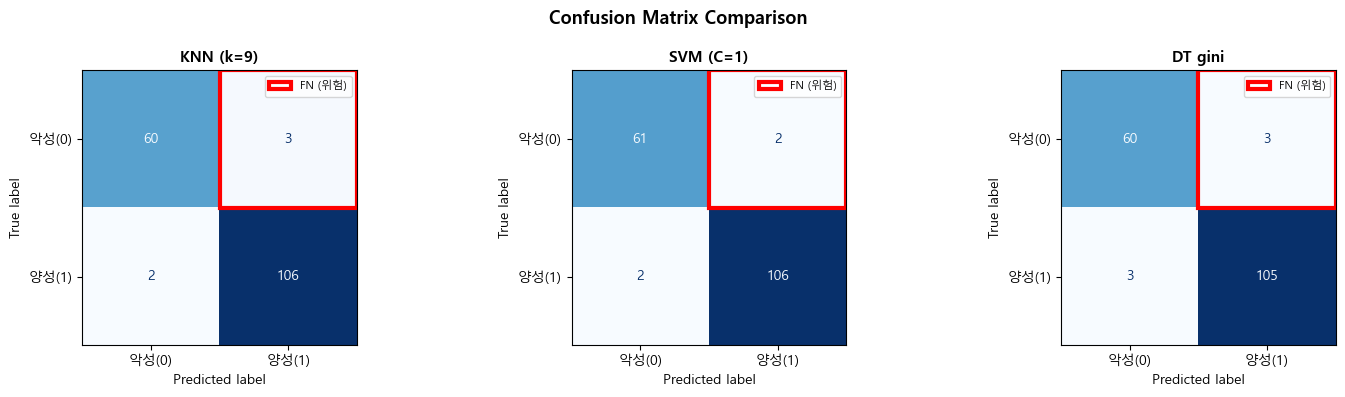

In [ ]:

# Confusion Matrix 3개 
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Confusion Matrix Comparison ', fontsize=13, fontweight='bold')

for ax, (name, pred) in zip(axes, [('KNN (k=9)', knn_pred),
                                     ('SVM (C=1)',    svm_pred),
                                     ('DT gini',      gini_pred)]):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['악성(0)', '양성(1)'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=11, fontweight='bold')
    # FN 강조 (악성을 양성으로 잘못 예측 — 가장 위험한 오류)
    ax.add_patch(plt.Rectangle((0.5, -0.5), 1, 1, fill=False,
                                edgecolor='red', lw=3, label='FN (위험)'))
    ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()

< confusion 매트릭스 분석 >
> 실제 암환자를 놓치지 않는 것이 가장 중요한 의료데이터의 특성상, FN이 적은 모델이 우수한 모델이다. 이때 knn 모델은 FN이 3개, svm은 2개, dt는 3개인 것을 확인할 수 있다. 따라서 3가지 모델 중 1개를 현장에서 사용한다면 FN이 가장 적은 svm 모델을 사용해야한다고 생각한다.

## 로지스틱 회귀, 랜덤포레스트, 그래디언트 부스팅

In [ ]:

# 로지스틱 회귀 모델, 랜덤포레스트, 그래디언트 부스팅

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score, classification_report)
import pandas as pd

# 모델 정의
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
}

# 각 모델 학습 및 평가
results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    results.append({
        'Model':     name,
        'Accuracy':  accuracy_score(y_test,  pred),
        'Precision': precision_score(y_test, pred, zero_division=0),
        'Recall':    recall_score(y_test,    pred, zero_division=0),
        'F1-Score':  f1_score(y_test,        pred, zero_division=0),
    })

# 결과 표 출력
result_df = pd.DataFrame(results).sort_values('F1-Score', ascending=False).reset_index(drop=True)
print('성능 비교표:')
display(result_df.round(4))

성능 비교표:


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.9825,0.9907,0.9815,0.9860
1,Random Forest,0.9708,0.9640,0.9907,0.9772
2,Gradient Boosting,0.9591,0.9633,0.9722,0.9677


< Logistic Regression, Random Forest, Gradient Boosting 3가지 모델 분석 >
>암 진단 데이터 분류 모델들을 분석한 결과, 로지스틱 회귀 모델이 accuracy(0.9825)와 pecision(0.9907)에서 우수하며 전반적으로 가장 적은 오진율을 기록하는 안정적인 성능을 보였다. 반면 랜덤 포레스트 모델은 정확도는 약간 낮지만 Recall 점수가 0.9907로 세 모델 중 가장 높게 나타났는데, 이는 실제 암 환자를 놓치지 않아야 하는 진단 모델의 핵심 목적에 가장 잘 맞는 특성이라 할 수 있다. 그래디언트 부스팅 모델은 모든 지표가 0.95 이상의 준수한 수치를 기록했으나 타 모델에 비해서는 전반적인 점수가 약간 낮다. 결론적으로 전체적인 예측 균형이 중요하다면 로지스틱 회귀를, FN을 방지하는 능력이 최우선이라면 랜덤 포레스트를 선택하는 것이 가장 합리적이라고 생각한다.

## 최적 모델 선택 


 최적 모델 선택 및 근거

> 3모델의 Accuracy를 보면 svm(0.9766)>knn(0.9708)>dt(0.9649)로 svm이 가장 우수하다. 하지만 유방암 진단 목적 특성 상 FN을 줄이는 것이 중요하므로 Recall값을 보면 svm(0.9815)=knn(0.9815)>dt(0.9722)이다. 따라서 Accuracy와 Recall값에서 모두 우수한 모델은 svm 모델이다.
의사/환자에게 설명 가능한가 관점에서 보면 knn은 가장 가까운k개의 샘플과 같은 클래스라는 직관적인 설명이 가능하지만 새로운 환자가 추가될 때마다 판단근거가 달라져 일관된 설명이 어렵다는 단점이 있다. 의사결정트리는 시각적으로 판단 근거를 보여줄 수도 있고 규칙이 존재하므로 각 기준이 정해져 있어서 명확한 설명이 가능하다. svm은 수학적 초평면으로 경계단면을 결정하고 일정 차원을 넘어가면 시각적으로 보여줄 수 없기 때문에 이 원리를 데이터분석이 전공이 아닌 의사나 환자에게 설명하기는 어렵다. 따라서 가장 설명이 쉬운 방법은 dt인 것 같다. 하지만 의료분야에서는 설명가능성보다 진단 정확도가 우선시 될 수 있다고 생각하기 때문에 이 점을 모델 선택에 중점으로 두기는 어렵다고 생각한다.
일반화 관점에서 보면 knn은 훈련데이터를 저장해두었다가 예측할 때 데이터와의 거리를 기반으로 판단하는데 만약 새로운 데이터가 기존 훈련데이터의 분포에서 벗어나면 잘못된 판단을 할 가능성이 매우 커질 수 있다. 의사결정트리는 최대 깊이가 제한이 없으면 훈련데이터에 과적합될 가능성이 매우 크고 깊이 제한과 리프 노드의 최소 샘플 수 등을 적절히 제한한다면 과적합에 대한 위험은 감소할 수 있다. svm은 목적함수에서 최대마진도 고려하는데 이것이 일반화를 위한 것이기 때문에 적절한 C값에서 과적합 위험, 과소적합 위험이 낮고 새로운 환자 데이터에도 안정적으로 작동할 가능성이 크다. 따라서 일반화 관점에서 가장 좋은 모델은 svm인 것 같다.
따라서 세 가지 관점을 종합해봤을 때 Breast Cancer 진단에 가장 적합한 모델은 svm이라고 생각한다.